In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import joblib

In [4]:
df = pd.read_csv('ga_selected_features2.csv')

In [5]:
df = df.replace({True: 1, False: 0})

In [6]:
df_sample = df.sample(n=5000, random_state=42)

In [5]:
df_sample.head()

,loan_percent_income,loan_intent_HOMEIMPROVEMENT,loan_grade_B,loan_grade_C,loan_grade_E,cb_person_default_on_file_Y
12377,-0.375510,1,1,0,0,0
20865,-1.124532,0,0,0,0,0
1328,-1.311788,0,1,0,0,0
18496,-1.311788,0,0,0,0,0
23653,-0.375510,0,0,1,0,1


In [6]:
df_sample['loan_percent_income'].max()

5.61666565512649

In [19]:
sample_indices = df_sample.index
df2 = pd.read_csv('cleaned_data.csv')
df_sample_again = df2.loc[sample_indices]
df_sample_again.head() 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
12377,26,85000,10.000000,11000,0.1199,0,0.13,4,False,False,...,False,False,False,True,False,False,False,False,False,False
20865,34,48989,10.000000,2400,0.0714,0,0.05,5,False,True,...,False,False,False,False,False,False,False,False,False,False
1328,22,36000,3.654551,1000,0.0988,0,0.03,3,False,False,...,True,False,False,True,False,False,False,False,False,False
18496,30,82500,5.000000,2400,0.0890,0,0.03,5,False,False,...,False,False,True,False,False,False,False,False,False,False
23653,30,72000,3.000000,9000,0.1422,0,0.13,6,False,False,...,True,False,False,False,True,False,False,False,False,True


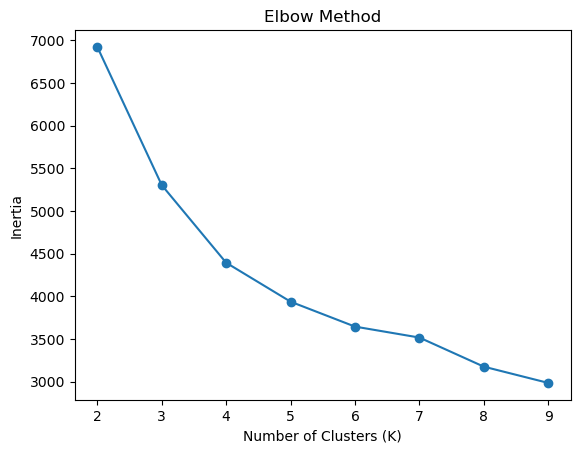

In [20]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMedoids(n_clusters=k, metric='manhattan', init='k-medoids++', random_state=42)
    model.fit(df_sample)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [7]:
k = 3  # choose based on elbow

model = KMedoids(
    n_clusters=k,
    metric="manhattan",
    init="k-medoids++",
    random_state=42
)

labels = model.fit_predict(df_sample)

print("Medoid Indices:", model.medoid_indices_) 

Medoid Indices: [207  83  15]


In [8]:
joblib.dump(model, "kmedoids.pkl")

['kmedoids.pkl']

In [8]:
score = silhouette_score(df_sample, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.24294647957252005


In [ ]:
for i in range(k):
    print(f"\nCluster {i}")
    print(df_sample[labels == i])


Cluster 0
       loan_percent_income loan_intent_HOMEIMPROVEMENT loan_grade_B  \
20865            -1.124532                           0            0   
18496            -1.311788                           0            0   
24301             0.279884                           0            0   
18947            -0.843649                           0            0   
15480            -1.124532                           0            0   
...                    ...                         ...          ...   
11355            -0.843649                           0            0   
4984             -0.188255                           0            0   
27412            -1.499043                           0            0   
30466            -1.218160                           0            0   
7594             -0.750021                           0            0   

      loan_grade_C loan_grade_E cb_person_default_on_file_Y  
20865            0            0                           0  
18496       

In [23]:
comparison = pd.crosstab(labels, df_sample_again['loan_status'])
print(comparison)

loan_status     0    1
row_0                 
0            1965  527
1             574  330
2            1337  267


#### Anaylsis

In [29]:
df_sample_again['K-Medoid_cluster'] = labels 

In [31]:
comparison = pd.crosstab(df_sample_again['K-Medoid_cluster'], df_sample_again['loan_status'], normalize='index') * 100
print(comparison)

loan_status               0          1
K-Medoid_cluster                      
0                 78.852327  21.147673
1                 63.495575  36.504425
2                 83.354115  16.645885


In [33]:
cluster_profile = df_sample_again.groupby('K-Medoid_cluster')[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']].mean()
print(cluster_profile)

                  person_age  person_income     loan_amnt  loan_int_rate  \
K-Medoid_cluster                                                           
0                  27.810995   67903.743178   8755.788523       0.100534   
1                  27.676991   61643.455752  11610.564159       0.140514   
2                  27.619701   64811.293641   9907.169576       0.110449   

                  loan_status  loan_percent_income  cb_person_cred_hist_length  
K-Medoid_cluster                                                                
0                    0.211477             0.152067                    5.802970  
1                    0.365044             0.218960                    5.797566  
2                    0.166459             0.174264                    5.743766  


# 📊 Credit Risk Clustering Analysis Report (K-Medoids)

---

## 1. Introduction
The objective of this analysis is to segment loan applicants into meaningful risk-based groups using **unsupervised learning (K-Medoids clustering)**.  

The clustering is performed on genetically selected financial features, aiming to identify distinct borrower profiles based on income behavior, loan characteristics, and credit history.

---

## 2. Methodology

### 2.1 Data Preparation
- The dataset was reduced using **Genetic Algorithm-based feature selection**
- Selected features include:
  - Loan percent income
  - Loan intent (encoded)
  - Loan grades (B, C, E)
  - Default history indicator

- All categorical variables were encoded into binary format (0/1), making them suitable for distance-based clustering.

---

### 2.2 Clustering Model
- **Algorithm:** K-Medoids Clustering  
- **Number of Clusters:** 3  
- **Input Data:** Scaled and encoded financial features  
- **Objective:** Group borrowers into homogeneous risk segments  

---

## 3. Cluster Statistical Summary

| Cluster | Avg Age | Avg Income | Avg Loan Amount | Avg Interest Rate | Loan % Income | Credit History Length | Default Rate |
|--------|---------|------------|------------------|-------------------|----------------|------------------------|--------------|
| **0** | 27.81 | 67,903 | 8,756 | 0.100 | 0.152 | 5.80 | 21.1% |
| **1** | 27.68 | 61,643 | 11,610 | 0.140 | 0.219 | 5.79 | 36.5% |
| **2** | 27.62 | 64,811 | 9,907 | 0.110 | 0.174 | 5.74 | 16.6% |

---

## 4. Cluster Interpretation

### 🟢 Cluster 2 — Low-Risk Customers
- **Default Rate:** ~16.6% (Lowest risk group)
- Customers in this cluster show:
  - Moderate loan-to-income ratio
  - Balanced financial behavior
  - Relatively stable credit patterns  

✔️ **Interpretation:**  
This group represents the most reliable borrowers and is considered **safe for lending**.

---

### 🔴 Cluster 1 — High-Risk Customers
- **Default Rate:** ~36.5% (Highest risk group)
- Characteristics:
  - Highest loan amounts
  - Highest loan percent income
  - Highest interest rates

⚠️ **Interpretation:**  
This cluster represents **financially stressed borrowers** with high likelihood of default due to heavy loan burden.

---

### 🟡 Cluster 0 — Moderate-Risk Customers
- **Default Rate:** ~21.1%
- Characteristics:
  - Highest average income
  - Lowest interest rate
  - Moderate loan burden

✔️ **Interpretation:**  
This is a **balanced customer segment**, showing acceptable risk but still requiring monitoring.

---

## 5. Key Insights

- The model successfully separated customers into **three clear risk segments**
- The most influential feature is **loan percent income**
- Higher loan burden and interest rates strongly correlate with default risk
- Genetic Algorithm improved clustering quality by selecting only relevant features

---

## 6. Conclusion & Recommendations

### ✔️ Cluster 2 (Low Risk)
- Suitable for standard and premium loan offers

### ⚠️ Cluster 0 (Medium Risk)
- Acceptable borrowers with normal conditions

### ❌ Cluster 1 (High Risk)
- Requires strict credit evaluation or collateral-based lending

---

## 7. Final Remark
K-Medoids clustering combined with Genetic Algorithm feature selection provides a **robust unsupervised credit risk segmentation system**, capable of identifying meaningful borrower profiles without labeled supervision.